In [1]:
!wget http://dl.caffe.berkeleyvision.org/bvlc_googlenet.caffemodel
!wget https://raw.githubusercontent.com/BVLC/caffe/master/models/bvlc_googlenet/deploy.prototxt
!wget https://raw.githubusercontent.com/HoldenCaulfieldRye/caffe/master/data/ilsvrc12/synset_words.txt
!wget http://farm4.staticflickr.com/3667/9279203548_d064d6802b_z.jpg -O image.jpg

--2018-10-18 05:51:42--  http://dl.caffe.berkeleyvision.org/bvlc_googlenet.caffemodel
Resolving dl.caffe.berkeleyvision.org (dl.caffe.berkeleyvision.org)... 169.229.222.251
Connecting to dl.caffe.berkeleyvision.org (dl.caffe.berkeleyvision.org)|169.229.222.251|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53533754 (51M) [application/octet-stream]
Saving to: ‘bvlc_googlenet.caffemodel’

bvlc_googlenet.caff 100%[===================>]  51.05M  30.8MB/s    in 1.7s    

2018-10-18 05:51:44 (30.8 MB/s) - ‘bvlc_googlenet.caffemodel’ saved [53533754/53533754]

--2018-10-18 05:51:45--  https://raw.githubusercontent.com/BVLC/caffe/master/models/bvlc_googlenet/deploy.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 151.101.0.133, 151.101.64.133, 151.101.128.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|151.101.0.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35862 (35K) [text/plain]

In [2]:
!ls

bvlc_googlenet.caffemodel  image.jpg	synset_words.txt
deploy.prototxt		   sample_data


In [3]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

PROTOTXT_DIR = 'deploy.prototxt'
MODEL_DIR = 'bvlc_googlenet.caffemodel'
LABEL_DIR = 'synset_words.txt'
IMAGE_DIR = 'image.jpg'

rows = open(LABEL_DIR).read().strip().split("\n")
CLASSES = [r[r.find(" ") + 1:].split(",")[0] for r in rows]
print(CLASSES)

['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', 'diamondback', 

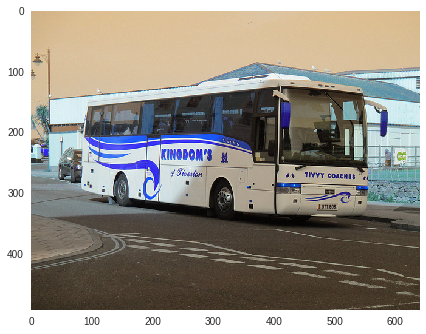

In [4]:
image = cv2.imread(IMAGE_DIR)
plt.rcParams["axes.grid"] = False
plt.imshow(image)
plt.show()

In [0]:
net = cv2.dnn.readNetFromCaffe(PROTOTXT_DIR, MODEL_DIR)
blob = cv2.dnn.blobFromImage(image, 1, (224, 224), (104, 117, 123))
net.setInput(blob)
result = net.forward()[0]

In [6]:
idxs = np.argsort(result)[::-1][:5]
for i, idx in enumerate(idxs):
  print(f"{CLASSES[idx]}, {result[idx]*100:.2f}%")

passenger car, 67.12%
trolleybus, 20.50%
minibus, 7.82%
school bus, 1.36%
recreational vehicle, 0.69%
